In [1]:
# 📦 Install required libraries
%pip install crewai==0.28.8 crewai_tools==0.1.6 langchain_community==0.0.29
%pip install langchain-groq
%pip install sentence-transformers
%pip install langchain_openai
%pip install "setuptools<=80.10.2"


  Using cached regex-2023.12.25-cp310-cp310-win_amd64.whl.metadata (41 kB)
Using cached regex-2023.12.25-cp310-cp310-win_amd64.whl (269 kB)
  Attempting uninstall: regex
    Found existing installation: regex 2026.7.10
    Uninstalling regex-2026.7.10:
      Successfully uninstalled regex-2026.7.10


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.13.0 requires regex>=2025.10.22, but you have regex 2023.12.25 which is incompatible.


Note: you may need to restart the kernel to use updated packages.
  Using cached regex-2026.7.10-cp310-cp310-win_amd64.whl.metadata (41 kB)
Using cached regex-2026.7.10-cp310-cp310-win_amd64.whl (277 kB)
  Attempting uninstall: regex
    Found existing installation: regex 2023.12.25
    Uninstalling regex-2023.12.25:
      Successfully uninstalled regex-2023.12.25
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
crewai 0.28.8 requires regex<2024.0.0,>=2023.12.25, but you have regex 2026.7.10 which is incompatible.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 📥 Import necessary packages and modules
from langchain_openai import ChatOpenAI
import os as os
from crewai_tools import PDFSearchTool
from langchain_community.tools.tavily_search import TavilySearchResults
from crewai_tools  import tool
from crewai import Crew
from crewai import Task
from crewai import Agent
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import pkg_resources

C:\Users\Rayha\Downloads\lib\site-packages\crewai\telemetry\telemetry.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
C:\Users\Rayha\Downloads\lib\site-packages\pydantic\_internal\_generate_schema.py:949: UserWarning: Mixing V1 models and V2 models (or constructs, like `TypeAdapter`) is not supported. Please upgrade `CrewAgentExecutor` to V2.
  warnings.warn(


In [3]:
# 🔐 Load API keys
GROQ_API_KEY='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'

# Expose the keys to the toolchain that reads environment variables
import os
os.environ['GROQ_API_KEY'] = GROQ_API_KEY


In [4]:
# 🧠 Set up the LLM model using Groq's Llama3
llm = ChatOpenAI(
    openai_api_base="https://api.groq.com/openai/v1",
    openai_api_key=GROQ_API_KEY,
    model_name="llama3-8b-8192",
    temperature=0.1,
    max_tokens=1000,
)

In [5]:
# 🔍 Define the PDF-based RAG tool with LLM and embedding model
rag_tool = PDFSearchTool(pdf='doc.pdf',
    config=dict(
        llm=dict(
            provider="groq", # or google, openai, anthropic, llama2, ...
            config=dict(
                model="llama3-8b-8192",
                temperature=0.5,
                top_p=1,
                stream=True,
            ),
        ),
        embedder=dict(
            provider="huggingface", # or openai, ollama, ...
            config=dict(
                model="BAAI/bge-small-en-v1.5",
                #task_type="retrieval_document",
                #title="Embeddings",
            ),
        ),
    )
)

2026-07-12 17:49:55,217 - 26452 - _http.py-_http:904 - WARNING: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# 🚀 Query the RAG tool to perform document-based search
rag_tool.run("What does Sporo Health do?")

Using Tool: Search a PDF's content


'Relevant Content:\nincreasing capabilities and token storage of LLMs in 2024 such as Google’s Med-Gemini, Meta’s Llama 3, OpenAI’s ChatGPT4, or Anthropic’s Claude 3.5, has allowed for these models to process the enormous portions of information for summarization and analysis. In recognition of the stringent accuracy, the need for personalization, privacy regulations, and the high knowledge floor needed for AI in clinical workflow, the innovation space gave birth to companies like Sporo Health to combat the aforementioned issues in clinical summarization using AI agents. Several case studies verify AI usage in various clinical settings to aid in chart review and summarization of clinical information. 3\n\nASSESSING THE ROLE OF CLINICAL SUMMARIZATION AND PATIENT CHART REVIEW WITHIN COMMUNICATIONS , MEDICAL MANAGEMENT ,AND DIAGNOSTICS Chanseo Lee Yale School of Medicine and Sporo Health New Haven, CT 06510 chanseo.lee@yale.eduKimon-Aristotelis Vogt Sporo Health Boston, MA 02134 kvogt@spo

In [3]:
#creating faiss index from PDF text file 
!pip install pypdf
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

In [4]:
pdf_path = r"C:\Users\Rayha\OneDrive\Documents\Data Science Internship 2026\RAG_App\crew_data\doc.pdf"

try:
    loader = PyPDFLoader(pdf_path)
    raw_documents = loader.load()
    print(f"✅ Loaded PDF successfully! Found {len(raw_documents)} pages.")
except Exception as e:
    print(f"❌ Error loading file: {e}")
    print("If you still get an error, verify the file isn't password protected or open in another program.")


✅ Loaded PDF successfully! Found 6 pages.


In [22]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,       # Targets optimal semantic size (~1-2 paragraphs)
    chunk_overlap=60,     # Keeps sliding context intact between splits
    length_function=len
)
split_docs = text_splitter.split_documents(raw_documents)
print(f"Split the PDF content into {len(split_docs)} individual text chunks.")

print("Initializing Hugging Face embedding model...")
embedding_model = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

print("Encoding text chunks into vector map (this may take a moment)...")
vector_store = FAISS.from_documents(split_docs, embedding_model)

db_directory = r"./faiss_db"
vector_store.save_local(db_directory)

print(f"\n🎉 Complete Success! Required FAISS index files saved to: {db_directory}")
print(f"Folder contents verify: {os.listdir(db_directory)}")

Split the PDF content into 46 individual text chunks.
Initializing Hugging Face embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding text chunks into vector map (this may take a moment)...

🎉 Complete Success! Required FAISS index files saved to: ./faiss_db
Folder contents verify: ['index.faiss', 'index.pkl']


In [14]:
#correcting initial errors with faiss index
!pip install faiss-cpu --force-reinstall

  Using cached faiss_cpu-1.14.3-cp310-cp310-win_amd64.whl.metadata (7.8 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
Using cached faiss_cpu-1.14.3-cp310-cp310-win_amd64.whl (16.2 MB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
Using cached packaging-26.2-py3-none-any.whl (100 kB)

  Attempting uninstall: packaging

    Found existing installation: packaging 26.2

    Uninstalling packaging-26.2:

      Successfully uninstalled packaging-26.2

   ---------------------------------------- 0/3 [packaging]
  Attempting uninstall: numpy
   ---------------------------------------- 0/3 [packaging]
    Found existing installation: numpy 2.2.6
   ---------------------------------------- 0/3 [packaging]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
    Uninstalling numpy-2.2.6:
   ------------- -------------------------- 1

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.1.13 requires numpy<2,>=1, but you have numpy 2.2.6 which is incompatible.
langchain-community 0.0.29 requires numpy<2,>=1, but you have numpy 2.2.6 which is incompatible.
langchain-core 0.1.53 requires packaging<24.0,>=23.2, but you have packaging 26.2 which is incompatible.
langgraph 1.2.8 requires langchain-core<2,>=1.4.7, but you have langchain-core 0.1.53 which is incompatible.
langgraph-checkpoint 4.1.1 requires langchain-core>=0.2.38, but you have langchain-core 0.1.53 which is incompatible.
langgraph-prebuilt 1.1.0 requires langchain-core>=1.3.1, but you have langchain-core 0.1.53 which is incompatible.
langgraph-sdk 0.4.2 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.1.53 which is incompatible.
langgraph-sdk 0.4.2 requires websockets<16,>=14, but you have websockets 16.1 whi

In [1]:
import faiss
print(faiss.__file__)  # Confirms the location of the package

# Test index creation
try:
    index = faiss.IndexFlatL2(64)
    print("Success! FAISS IndexFlatL2 is working properly.")
except AttributeError as e:
    print(f"Error still persists: {e}")


C:\Users\Rayha\Downloads\lib\site-packages\faiss\__init__.py
Success! FAISS IndexFlatL2 is working properly.


In [6]:
##1: SIMILARITY SEARCH USING FAISS INDEX 

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

db_directory = r"./faiss_db"
vector_store = FAISS.load_local(
    folder_path=db_directory, 
    embeddings=embedding_model,
    allow_dangerous_deserialization=True
)

query = "How is AI relevant to clinical trials?"
results = vector_store.similarity_search(query, k=3)

print(f"Retrieved {len(results)} relevant chunks from your PDF:\n")
for i, doc in enumerate(results, start=1):
    print(f"--- Matching Section #{i} (Page {doc.metadata.get('page', 'Unknown')}) ---")
    print(f"{doc.page_content}\n")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Retrieved 3 relevant chunks from your PDF:

--- Matching Section #1 (Page 4) ---
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
range of data types and clinical scenarios. Additionally, the ethical implications of AI in healthcare, such as racial or
socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
need to be carefully considered.
References
[1]O’Malley AS, Cohen GR, Grossman JM. Electronic medical records and communication with patients and other

--- Matching Section #2 (Page 2) ---
3.5, has allowed for these models to process the enormous portions of information for summarization and analysis.
In recognition of the stringent accuracy, the need for personalization, privacy regulations, and the high knowledge
floor needed for AI in clinical workflow, the innovation space gave birth to companies like Sporo Health to combat
the aforementioned issues in clinic

In [7]:
##2 VISUALISING EMBEDDINGS USING t-SNE
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

def get_sentences_and_categories():
    sentences = [
        """As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
         range of data types and clinical scenarios.""",
        """Additionally, the ethical implications of AI in healthcare, such as racial or socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
         need to be carefully considered.""",
        """In recognition of the stringent accuracy, the need for personalization, privacy regulations, and the high knowledge
         floor needed for AI in clinical workflow, the innovation space gave birth to companies like Sporo Health to combat
         the aforementioned issues in clinical summarization using AI agents.""",
        "Several case studies verify AI usage in various clinical settings to aid in chart review and summarization of clinical information.",
        """[20]Both clinical-sided physician evaluation of comprehensibility, accuracy, redundancy, and readability as well as standard
         AI-sided quantitative evaluation using s ROUGE or BERTscore[21][22]was performed on the summarization capabilities
         of these models."""
    ]
    categories = (["AI"] * 8 + ["clinical"] * 8 + ["models"] * 8)
    return sentences, categories

    def get_colour_and_shape_maps():
        colour_map = {"AI": "red", "clinical": "blue", "models": "green"}
        shape_map =  {"AI": "o", "clinical": "s", "models": "^"}

In [8]:
#generating embeddings in t-sne model #all-MiniLM-L6-v2
model_name="sentence-transformers/BAAI/bge-small-en-v1.5"
def compute_tsne_embeddings(sentences, model_name="sentence-transformers/BAAI/bge-small-en-v1.5",
                            perplexity=10, n_iter=3000, random_state=42):
    model = SentenceTransformer(model_name)
    embeddings = model.encode(sentences)
    tsne = TSNE(n_components=2, random_state=random_state, perplexity=perplexity, n_iter=n_iter) #2-dimensional e for n_components
    
    return tsne.fit_transform(embeddings)

NameError: name 'xlim' is not defined

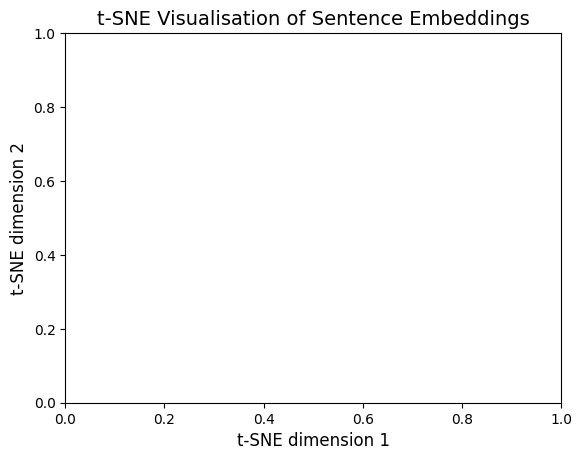

In [10]:
#plotting embeddings
import matplotlib.pyplot as plt
def plot_embeddings(reduced_embeddings, sentences, categories, colour_map, shape_map,
                    xlim=(-125,150), ylim=(-175,125)):
    plt.figure(figsize=(10,8))

    for i, (sentence, category), in enumerate(zip(sentences, categories)):
        x, y = reduced_embeddings[i]
        plt.scatter(x, y, colour=colour_map[category], marker=shape_map[category])
        plt.text(x - 2.5, y - 7.5, sentence[:20] + "...", fontsize=9)
    
    for cat, colour in colour_map.items():
        plt.scatter([], [], colour=colour, label=cat, marker=shape_map[cat])
    plt.legend(loc="best")

#labels

plt.title("t-SNE Visualisation of Sentence Embeddings", fontsize=14)
plt.xlabel("t-SNE dimension 1", fontsize=12)
plt.ylabel("t-SNE dimension 2", fontsize=12)
plt.xlim(*xlim)
plt.ylim(*ylim)
plt.savefig('tsne_plot.png')#saving as image file

In [24]:
##REBUILDING FAISS INDEX WITH NEW DOCUMENTS
embedding_model_name = "BAAI/bge-small-en-v1.5"
embeddings = HuggingFaceEmbeddings(model_name=embedding_model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
index_directory = "./faiss_db"

if os.path.exists(index_directory):
    print(f"Loading existing FAISS index from '{index_directory}'...")
    db = FAISS.load_local(
        index_directory, 
        embeddings, 
        allow_dangerous_deserialization=True
    )
else:
    raise FileNotFoundError(f"Could not find existing index folder at {index_directory}")

Loading existing FAISS index from './faiss_db'...


In [26]:
new_pdf_files = ["Observational Rainfall Data.pdf", "Reactivity of Ambient Aerosol Particles.pdf", "Responsible Data Sharing for Donors.pdf"]
all_new_chunks = []

In [27]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

In [28]:
for pdf_path in new_pdf_files:
    if os.path.exists(pdf_path):
        print(f"Processing: {pdf_path}")
        loader = PyPDFLoader(pdf_path)

Processing: Observational Rainfall Data.pdf
Processing: Reactivity of Ambient Aerosol Particles.pdf
Processing: Responsible Data Sharing for Donors.pdf


In [30]:
pages = loader.load()
chunks = text_splitter.split_documents(pages)

In [39]:
all_new_chunks.extend(chunks)

if all_new_chunks:
    print(f"Adding {len(all_new_chunks)} text segments to the FAISS index...")
    db.add_documents(all_new_chunks)
else:
    print(f"⚠️ Warning: {pdf_path} not found. Skipping.")  

Adding 50 text segments to the FAISS index...


In [43]:
db.save_local(index_directory)
print("✅ FAISS index successfully updated and saved!")

✅ FAISS index successfully updated and saved!


In [50]:
##TESTING NEW QUERIES WITH UPDATED FAISS INDEX
query = "What models are used in all four documents?"

print(f"\nSearching for: '{query}'\n" + "-"*50)
results = db.similarity_search_with_score(query, k=3)

for i, (doc, score) in enumerate(results, start=1):
    source_file = doc.metadata.get("source", "Unknown Source")
    page_number = doc.metadata.get("page", "Unknown Page")
    
    if isinstance(page_number, int):
        page_number += 1
        print(f"Match #{i} (Distance Score: {score:.4f})")
    print(f"📄 Source File: {source_file}")
    print(f"📖 Page: {page_number}")
    print(f"📝 Text Snippet:\n{doc.page_content.strip()}")
    print("-" * 50)


Searching for: 'What models are used in all four documents?'
--------------------------------------------------
Match #1 (Distance Score: 0.6497)
📄 Source File: C:\Users\Rayha\OneDrive\Documents\Data Science Internship 2026\RAG_App\crew_data\doc.pdf
📖 Page: 4
📝 Text Snippet:
volumes of data into digestible summaries, although challenges such as maintaining accuracy and managing large
datasets persists.[19]
7 Capabilities of Large Language Models with Patient Charts
A recent study published in Nature Medicine evaluated the leading Large Language Models (LLMs) in their ability to
summarize clinical information in patient charts.[23]Eight open source and proprietary models including ChatGPT3.5,
ChatGPT4, LLaMa-2, Med-Alpaca, which were then adapted to the summarization tasks at hand using in-context
--------------------------------------------------
Match #2 (Distance Score: 0.7165)
📄 Source File: C:\Users\Rayha\OneDrive\Documents\Data Science Internship 2026\RAG_App\crew_data\doc.pdf
📖 

In [ ]:
#Distance scores are quite high (closer to 1.0 than 0), indicating less relevant information being found. 
#This may have been due to all documents being about vastly different topics from each other